# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [1]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [2]:
# !mkdir -p data
# !wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

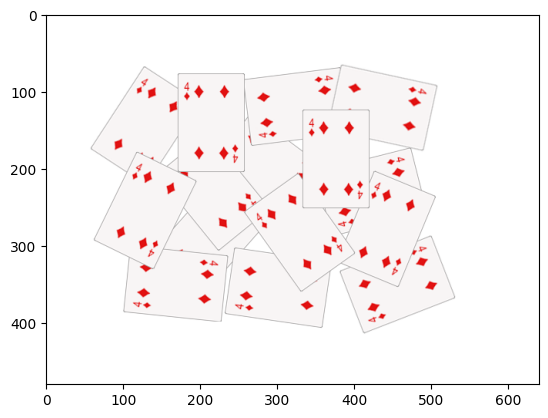

In [2]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

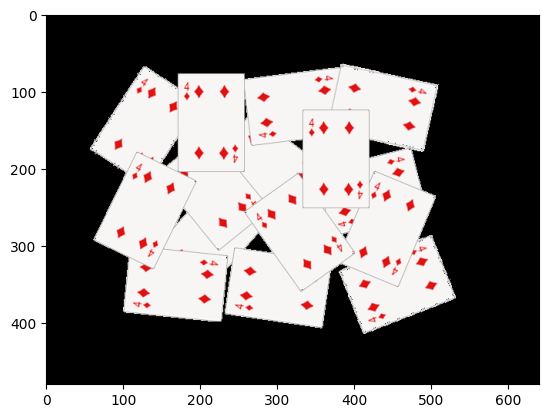

In [3]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

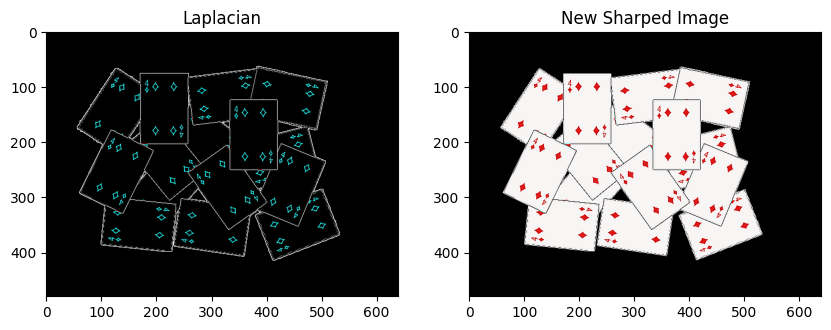

In [4]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

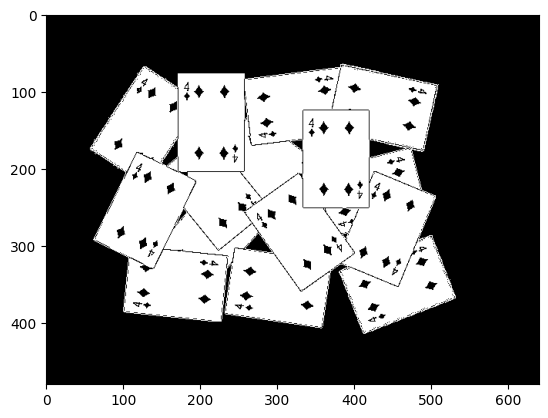

In [5]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

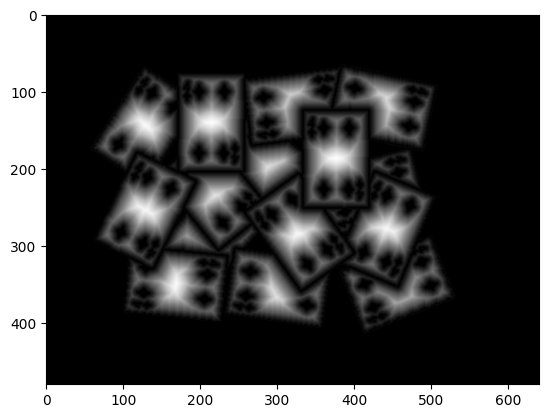

In [6]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

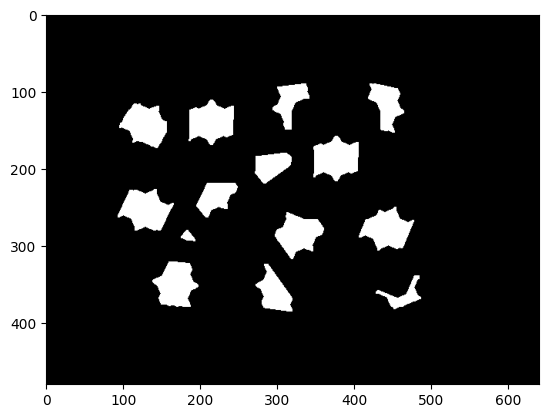

In [7]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

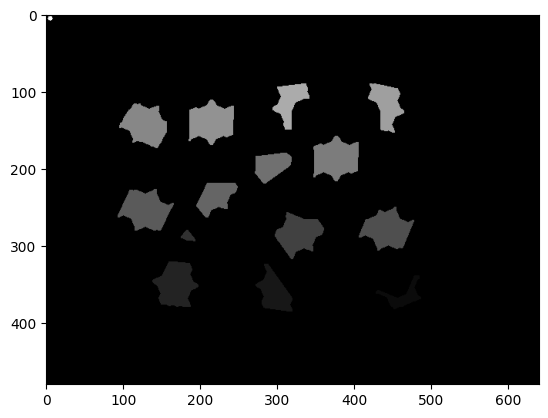

In [8]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

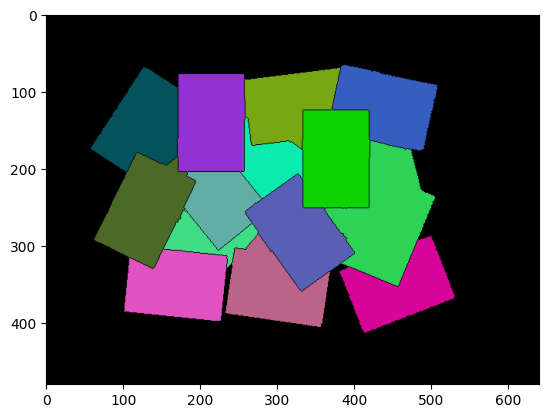

In [9]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

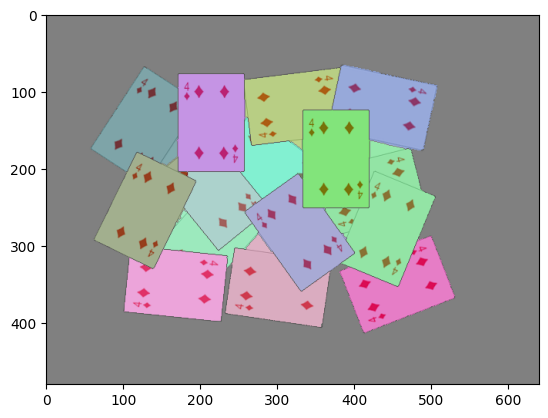

In [10]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

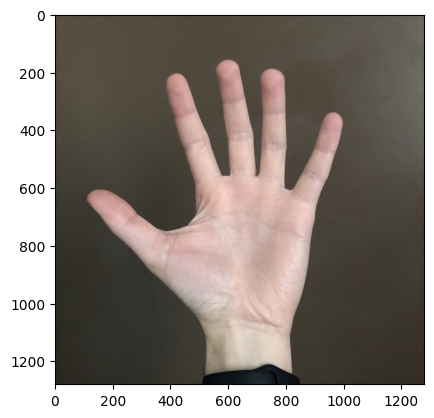

In [11]:
# Замените путь на фото своей руки (разные кадры для жестов 0–5 пальцев).
# Если файлав нет, один раз скачайте отладочный пример (как `cards.png` выше):
# !mkdir -p data && curl -L -o data/hand.jpg https://raw.githubusercontent.com/opencv/opencv/4.x/doc/js_tutorials/js_assets/handSrc.jpg

IMAGE_PATH = "data/hand.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(
        f"Не найден {IMAGE_PATH}. Положите свой снимок в data/ или выполните curl из комментария."
    )
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

In [12]:
def make_skin_mask(bgr: np.ndarray) -> np.ndarray:
    """Бинарная маска кожи в HSV + морфология для цельного контура."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    lo1, hi1 = np.array([0, 30, 50], np.uint8), np.array([25, 255, 255], np.uint8)
    lo2, hi2 = np.array([170, 30, 50], np.uint8), np.array([180, 255, 255], np.uint8)
    mask = cv2.bitwise_or(cv2.inRange(hsv, lo1, hi1), cv2.inRange(hsv, lo2, hi2))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    return mask


def largest_hand_contour(mask: np.ndarray):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)


def filter_convexity_defects(defects, cnt, perimeter: float, solidity: float):
    """Оставляем глубокие впадины с «острым» углом в дне — между пальцами."""
    if solidity > 0.92:
        return 0, []
    if defects is None:
        return 1, []

    min_depth = 0.01 * perimeter
    max_angle = np.deg2rad(95)
    accepted = []
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        if d < 1:
            continue
        depth = d / 256.0
        if depth < min_depth:
            continue
        p_s, p_e, p_f = cnt[s][0].astype(float), cnt[e][0].astype(float), cnt[f][0].astype(float)
        a = np.linalg.norm(p_s - p_f)
        b = np.linalg.norm(p_e - p_f)
        c = np.linalg.norm(p_s - p_e)
        if a < 1.0 or b < 1.0:
            continue
        cos_a = float(np.clip((a * a + b * b - c * c) / (2 * a * b), -1.0, 1.0))
        if float(np.arccos(cos_a)) < max_angle:
            accepted.append((int(s), int(e), int(f), depth))

    fingers = int(np.clip(len(accepted) + 1, 0, 5))
    return fingers, accepted


def analyze_hand(bgr: np.ndarray):
    mask = make_skin_mask(bgr)
    cnt = largest_hand_contour(mask)
    if cnt is None:
        raise RuntimeError("Контур не найден: освещение, фон или маска кожи.")

    hull_idx = cv2.convexHull(cnt, returnPoints=False)
    if hull_idx is None or len(hull_idx) < 3:
        return mask, cnt, 0, None, None, [], 0.0

    hull = cv2.convexHull(cnt)
    area, hull_area = cv2.contourArea(cnt), cv2.contourArea(hull)
    solidity = float(area / hull_area) if hull_area > 1e-6 else 0.0
    perimeter = cv2.arcLength(cnt, True)
    defects = cv2.convexityDefects(cnt, hull_idx)
    fingers, accepted = filter_convexity_defects(defects, cnt, perimeter, solidity)
    return mask, cnt, fingers, hull, defects, accepted, solidity


def draw_finger_estimate(bgr, cnt, fingers, hull, accepted):
    vis = bgr.copy()
    if hull is not None:
        cv2.drawContours(vis, [hull], -1, (255, 0, 0), 2)
    cv2.drawContours(vis, [cnt], -1, (0, 255, 0), 2)
    for s, e, f, _dep in accepted:
        cv2.circle(vis, tuple(cnt[f][0]), 7, (0, 0, 255), -1)
    cv2.putText(
        vis,
        f"fingers ~ {fingers}",
        (16, 44),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.1,
        (0, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return vis


mask, cnt, fingers, hull, defects, accepted, solidity = analyze_hand(img_bgr)

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(img)
ax[0].set_title("Вход RGB")
ax[1].imshow(mask, cmap="gray")
ax[1].set_title("Бинарная маска (кожа)")
res_bgr = draw_finger_estimate(img_bgr, cnt, fingers, hull, accepted)
ax[2].imshow(cv2.cvtColor(res_bgr, cv2.COLOR_BGR2RGB))
ax[2].set_title(
    f"Convex hull + дефекты выпуклости\nПальцев: {fingers}, solidity={solidity:.2f}, дефектов: {len(accepted)}"
)
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

print(f"Оценка числа пальцев: {fingers} (после фильтрации осталось дефектов: {len(accepted)})")


NameError: name 'img_bgr' is not defined

In [ ]:
# Чтобы выполнить требование ДЗ (жесты с 0 по 5 пальцев), добавьте свои файлы и перечислите пары (путь, подпись):
from pathlib import Path

MY_HAND_SHOTS = [
    ("data/hand.jpg", "отладка (пример OpenCV)"),
    # ("data/me_fist.jpg", "0 пальцев"),
    # ("data/me_one.jpg", "1 палец"),
    # ("data/me_five.jpg", "5 пальцев"),
]

rows = []
for path, caption in MY_HAND_SHOTS:
    p = Path(path)
    if not p.is_file():
        print(f"Пропуск: нет файла {path}")
        continue
    bgr = cv2.imread(str(p))
    if bgr is None:
        print(f"Не удалось прочитать {path}")
        continue
    try:
        _m, _c, n, _h, _defc, acc, sol = analyze_hand(bgr)
    except RuntimeError as e:
        print(path, e)
        continue
    rows.append((caption, path, n, len(acc), sol))
    print(f"{caption!r} ({path}): пальцев ~ {n}, дефектов после фильтра: {len(acc)}, solidity={sol:.2f}")

if len(rows) > 1:
    print("\nСводка:", rows)
